# AI-Powered Smart Manufacturing & Green Energy Optimization

## Project Overview

This project develops an AI-powered decision-support framework for smart
manufacturing and industrial energy optimization.

The project combines two complementary datasets:

1. Smart manufacturing machine-condition data
2. Industrial energy consumption and production data

The objective is to use data analytics and machine learning to improve machine
reliability, identify operational risks, understand industrial energy
consumption, and develop practical energy-efficiency recommendations.

## Business Problem

Manufacturing companies must maintain reliable production while controlling
energy consumption, reducing machine downtime, and improving operational
efficiency.

This project investigates how machine learning and data analytics can support
these objectives.

## Project Objectives

- Analyze machine operating conditions.
- Identify abnormal machine behavior.
- Predict maintenance requirements.
- Analyze machine energy consumption.
- Examine the relationship between energy consumption and production output.
- Identify energy-inefficient operating conditions.
- Develop machine learning models for predictive decision-making.
- Develop an energy optimization recommendation framework.
- Build an interactive Streamlit application.
- Present the complete project through GitHub.

## Final Deliverable

The final solution will combine predictive maintenance and energy analytics
into an interactive Streamlit application that provides actionable insights
for smart manufacturing and energy efficiency.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

In [8]:
manufacturing_df = pd.read_csv(
    "smart_manufacturing_data.csv"
)

energy_df = pd.read_csv(
    "Energy_dataset.csv"
)

manufacturing_df["timestamp"] = pd.to_datetime(
    manufacturing_df["timestamp"]
)

energy_df["timestamp"] = pd.to_datetime(
    energy_df["timestamp"]
)

print("Smart Manufacturing:", manufacturing_df.shape)
print("Energy Dataset:", energy_df.shape)

Smart Manufacturing: (100000, 13)
Energy Dataset: (1200, 20)


# 1. Smart Manufacturing Data Analysis

The smart manufacturing dataset provides machine-level information about
operating conditions, energy consumption, machine status, anomalies,
maintenance requirements, downtime risk, and remaining useful life.

This dataset will form the predictive-maintenance component of the project.

The primary machine-learning objective is to determine whether a machine
requires maintenance based on its observed operating conditions.

In [9]:
manufacturing_df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.610,28.650,79.960,3.730,2.160,1,0,106,Normal,0.000,0
1,2025-01-01 00:01:00,29,68.190,57.280,35.940,3.640,0.690,1,0,320,Normal,0.000,0
2,2025-01-01 00:02:00,15,98.940,50.200,72.060,1.000,2.490,1,1,19,Normal,1.000,1
3,2025-01-01 00:03:00,43,90.910,37.650,30.340,3.150,4.960,1,1,10,Normal,1.000,1
4,2025-01-01 00:04:00,8,72.320,40.690,56.710,2.680,0.630,2,0,65,Vibration Issue,0.000,1


In [10]:
manufacturing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

In [11]:
manufacturing_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,100000,NaN,NaN,NaN,2025-02-04 17:19:29.999999744,2025-01-01 00:00:00,2025-01-18 08:39:45,2025-02-04 17:19:30,2025-02-22 01:59:15,2025-03-11 10:39:00,NaN
machine_id,100000.000,NaN,NaN,NaN,25.499,1.000,13.000,25.000,38.000,50.000,14.389
temperature,100000.000,NaN,NaN,NaN,75.016,35.550,68.267,75.060,81.750,121.940,10.032
vibration,100000.000,NaN,NaN,NaN,50.012,-17.090,39.970,49.960,60.100,113.800,14.985
humidity,100000.000,NaN,NaN,NaN,54.995,30.000,42.520,54.980,67.500,80.000,14.438
pressure,100000.000,NaN,NaN,NaN,3.000,1.000,2.000,3.010,4.000,5.000,1.152
energy_consumption,100000.000,NaN,NaN,NaN,2.747,0.500,1.630,2.740,3.870,5.000,1.298
machine_status,100000.000,NaN,NaN,NaN,1.002,0.000,1.000,1.000,1.000,2.000,0.446
anomaly_flag,100000.000,NaN,NaN,NaN,0.089,0.000,0.000,0.000,0.000,1.000,0.285
predicted_remaining_life,100000.000,NaN,NaN,NaN,234.269,1.000,97.000,230.000,365.000,499.000,150.063


In [12]:
print("Missing values:")
display(manufacturing_df.isnull().sum())

print("\nDuplicate rows:")
print(manufacturing_df.duplicated().sum())

Missing values:


timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64


Duplicate rows:
0


In [16]:
print("Number of machines:")
print(manufacturing_df["machine_id"].nunique())

print("\nMachine IDs:")
print(sorted(manufacturing_df["machine_id"].unique()))

Number of machines:
50

Machine IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


In [17]:
print("Maintenance required:")
display(
    manufacturing_df["maintenance_required"]
    .value_counts()
    .to_frame("count")
)

print("\nMaintenance percentage:")
display(
    (
        manufacturing_df["maintenance_required"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_frame("percentage")
    )
)

Maintenance required:


,count
maintenance_required,
0,80303
1,19697



Maintenance percentage:


,percentage
maintenance_required,
0,80.300
1,19.700


In [18]:
print("Anomaly flag:")
display(
    manufacturing_df["anomaly_flag"]
    .value_counts()
    .to_frame("count")
)

print("\nDowntime risk:")
display(
    manufacturing_df["downtime_risk"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

Anomaly flag:


,count
anomaly_flag,
0,91084
1,8916



Downtime risk:


,count
downtime_risk,
0.000,91084
0.880,1
0.920,1
0.930,1
0.940,1
0.970,2
0.980,3
0.990,3
1.000,8904


## Business Question 1

### Which machines have the highest maintenance requirement?

Understanding maintenance patterns by machine can help manufacturing
management identify equipment requiring greater preventive-maintenance
attention.

A machine with a consistently high maintenance rate may indicate unfavorable
operating conditions, higher wear, or greater operational risk.

In [19]:
machine_maintenance = (
    manufacturing_df
    .groupby("machine_id")["maintenance_required"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

machine_maintenance.head(10)

machine_id
43   21.511
50   21.444
24   21.069
32   20.975
5    20.950
29   20.890
30   20.878
6    20.838
42   20.654
4    20.609
Name: maintenance_required, dtype: float64

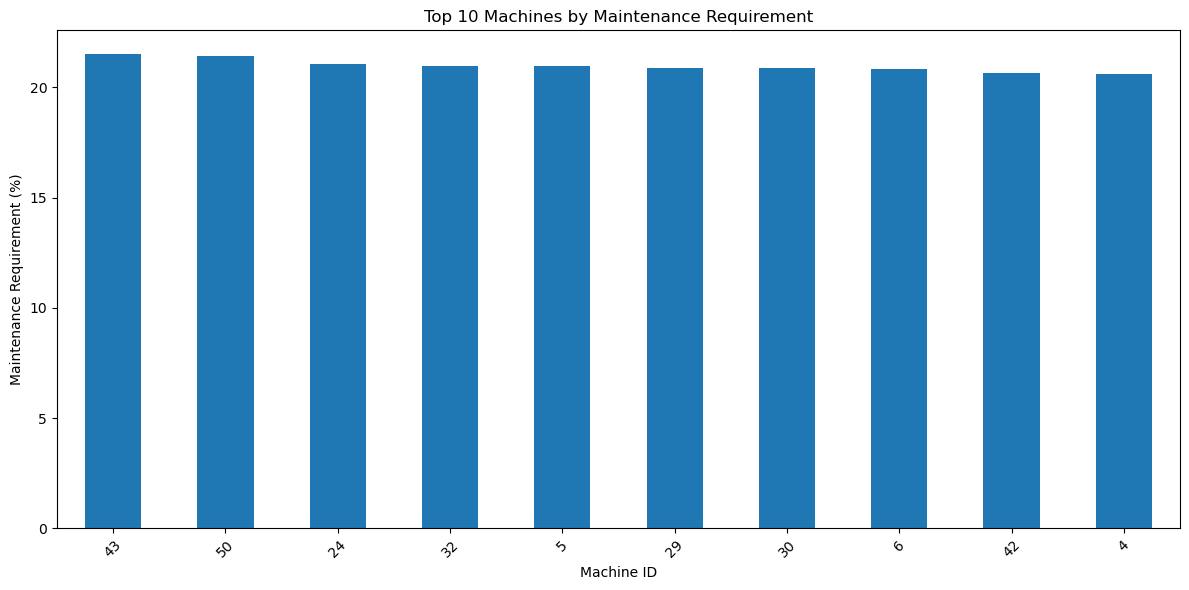

In [20]:
plt.figure(figsize=(12, 6))

machine_maintenance.head(10).plot(kind="bar")

plt.title("Top 10 Machines by Maintenance Requirement")
plt.xlabel("Machine ID")
plt.ylabel("Maintenance Requirement (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Question 2

### How do operating conditions differ between machines requiring maintenance
and those that do not?

Temperature, vibration, humidity, pressure, energy consumption, and machine
status are examined to identify potential relationships with maintenance
requirements.

These variables will later be considered as potential predictors in the
machine-learning model.

In [21]:
maintenance_summary = (
    manufacturing_df
    .groupby("maintenance_required")[
        [
            "temperature",
            "vibration",
            "humidity",
            "pressure",
            "energy_consumption",
            "predicted_remaining_life",
            "downtime_risk"
        ]
    ]
    .mean()
)

maintenance_summary

,temperature,vibration,humidity,pressure,energy_consumption,predicted_remaining_life,downtime_risk
maintenance_required,,,,,,,
0,73.609,49.173,55.023,3.002,2.746,259.760,0.000
1,80.748,53.434,54.884,2.996,2.751,130.344,0.453


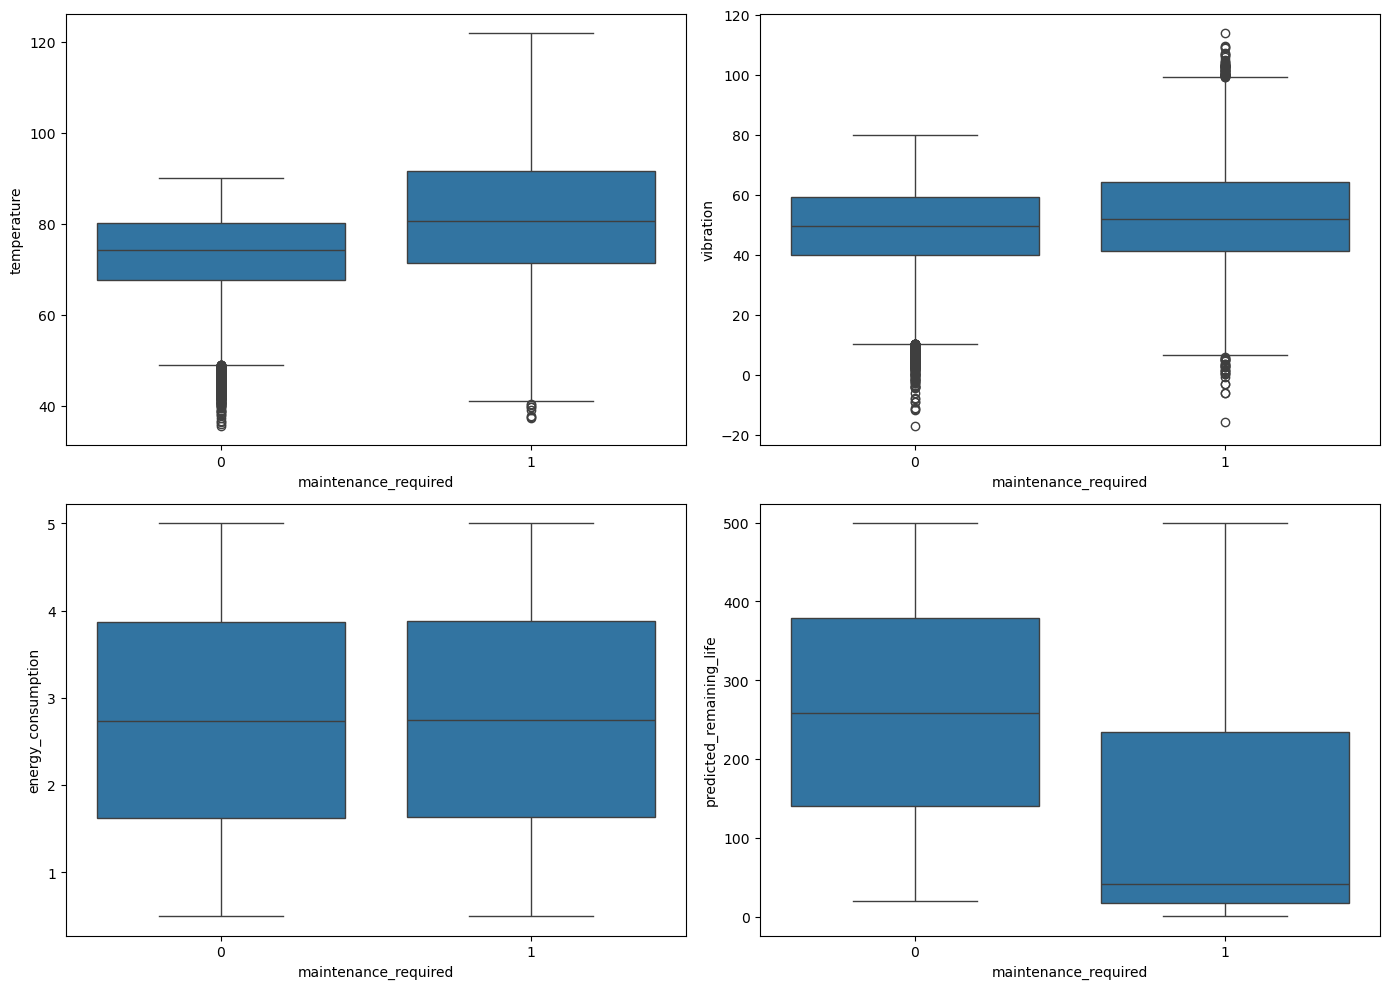

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(
    data=manufacturing_df,
    x="maintenance_required",
    y="temperature",
    ax=axes[0, 0]
)

sns.boxplot(
    data=manufacturing_df,
    x="maintenance_required",
    y="vibration",
    ax=axes[0, 1]
)

sns.boxplot(
    data=manufacturing_df,
    x="maintenance_required",
    y="energy_consumption",
    ax=axes[1, 0]
)

sns.boxplot(
    data=manufacturing_df,
    x="maintenance_required",
    y="predicted_remaining_life",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

## Business Question 3

### Which numerical variables are most strongly associated with maintenance
and machine risk?

Correlation analysis provides an initial understanding of relationships among
machine operating variables.

Correlation does not establish causation. It is used here as an exploratory
tool to guide feature selection and subsequent modelling.

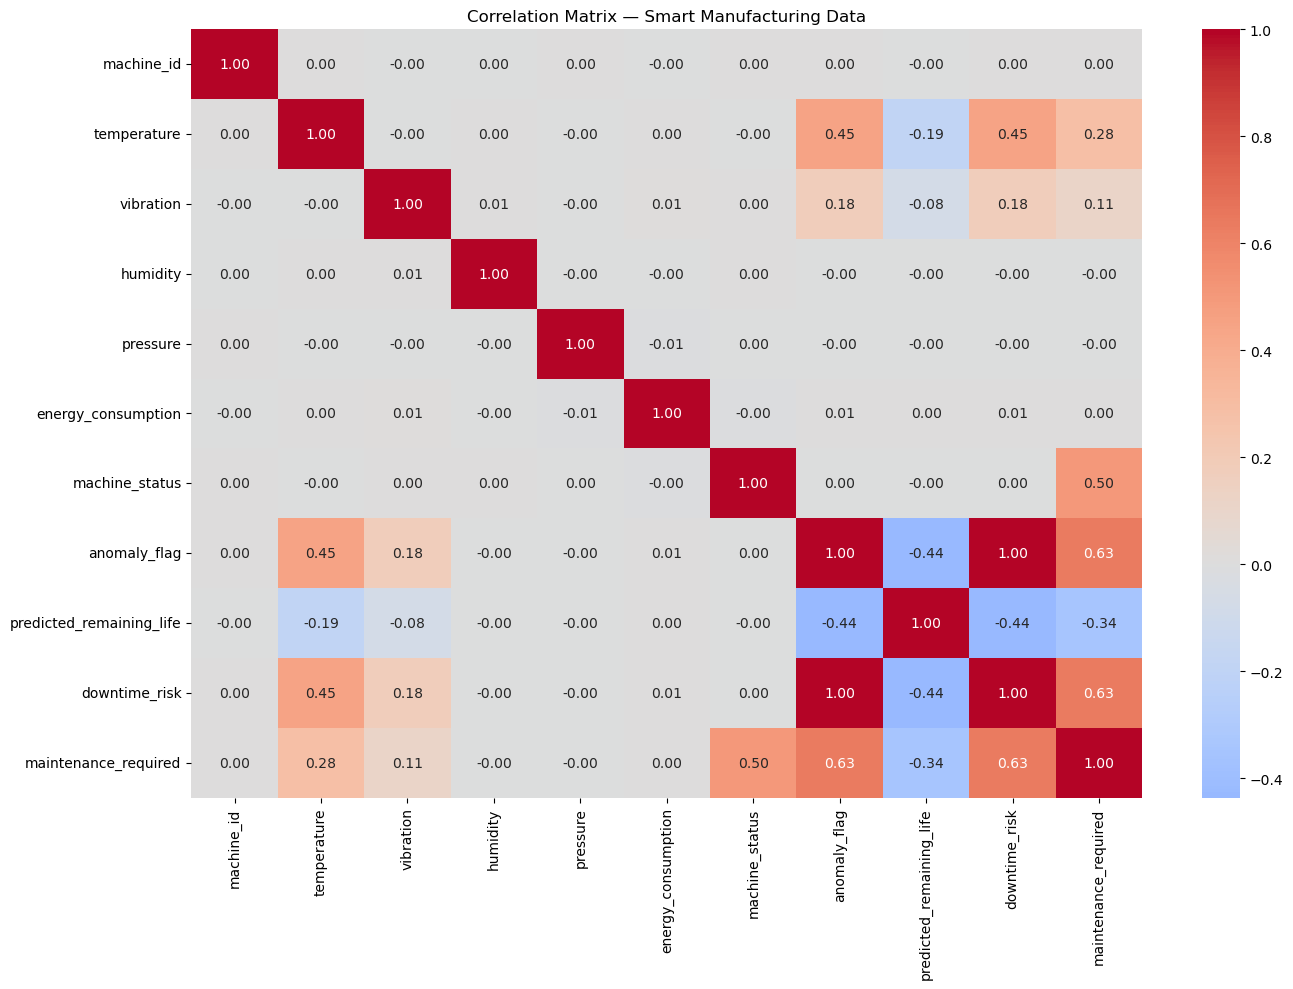

In [23]:
numeric_cols = manufacturing_df.select_dtypes(
    include=np.number
).columns

correlation_matrix = manufacturing_df[
    numeric_cols
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Smart Manufacturing Data")
plt.tight_layout()
plt.show()

## Business Question 4

### Are machine anomalies associated with maintenance requirements?

An important objective of predictive maintenance is to determine whether
abnormal machine behavior can provide an early warning of maintenance needs.

The relationship between anomaly detection and maintenance requirements is
examined using a contingency table and maintenance rates.

In [24]:
anomaly_maintenance = pd.crosstab(
    manufacturing_df["anomaly_flag"],
    manufacturing_df["maintenance_required"],
    margins=True
)

anomaly_maintenance

maintenance_required,0,1,All
anomaly_flag,,,
0,80303,10781,91084
1,0,8916,8916
All,80303,19697,100000


In [25]:
anomaly_maintenance_rate = (
    manufacturing_df
    .groupby("anomaly_flag")["maintenance_required"]
    .mean()
    .mul(100)
    .round(2)
)

anomaly_maintenance_rate

anomaly_flag
0    11.840
1   100.000
Name: maintenance_required, dtype: float64

In [26]:
categorical_columns = manufacturing_df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['failure_type'], dtype='object')

In [27]:
for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(manufacturing_df[column].value_counts())


failure_type
failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64


## Business Question 5

### Which machine states or failure types are associated with maintenance?

Categorical operating conditions are compared using maintenance rates.

This helps determine whether particular machine states or failure categories
are associated with a higher probability of maintenance.

In [28]:
for column in categorical_columns:
    print("\n" + "=" * 60)
    print(f"Maintenance Rate by {column}")
    print("=" * 60)

    result = (
        manufacturing_df
        .groupby(column)["maintenance_required"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
    )

    display(result)


Maintenance Rate by failure_type


failure_type
Electrical Fault   100.000
Overheating        100.000
Pressure Drop      100.000
Vibration Issue    100.000
Normal              12.620
Name: maintenance_required, dtype: float64

In [29]:
manufacturing_df.columns.tolist()

['timestamp',
 'machine_id',
 'temperature',
 'vibration',
 'humidity',
 'pressure',
 'energy_consumption',
 'machine_status',
 'anomaly_flag',
 'predicted_remaining_life',
 'failure_type',
 'downtime_risk',
 'maintenance_required']

In [30]:
manufacturing_df.dtypes

timestamp                   datetime64[ns]
machine_id                           int64
temperature                        float64
vibration                          float64
humidity                           float64
pressure                           float64
energy_consumption                 float64
machine_status                       int64
anomaly_flag                         int64
predicted_remaining_life             int64
failure_type                        object
downtime_risk                      float64
maintenance_required                 int64
dtype: object

## Data Leakage Investigation

The exploratory analysis indicates that some variables may contain information
that is directly related to the maintenance decision.

For example, all observations with an anomaly flag of 1 require maintenance,
while all identified failure types also have a 100% maintenance rate.

These variables will therefore be investigated for potential target leakage
before machine-learning model development.

In [31]:
failure_maintenance = pd.crosstab(
    manufacturing_df["failure_type"],
    manufacturing_df["maintenance_required"],
    margins=True
)

failure_maintenance

maintenance_required,0,1,All
failure_type,,,
Electrical Fault,0,1014,1014
Normal,80303,11596,91899
Overheating,0,1989,1989
Pressure Drop,0,1969,1969
Vibration Issue,0,3129,3129
All,80303,19697,100000


In [32]:
# Check whether anomaly and failure type together determine maintenance

pd.crosstab(
    [
        manufacturing_df["anomaly_flag"],
        manufacturing_df["failure_type"]
    ],
    manufacturing_df["maintenance_required"],
    margins=True
)

maintenance_required               0      1     All
anomaly_flag failure_type                          
0            Electrical Fault      0    914     914
             Normal            80303   3437   83740
             Overheating           0   1814    1814
             Pressure Drop         0   1779    1779
             Vibration Issue       0   2837    2837
1            Electrical Fault      0    100     100
             Normal                0   8159    8159
             Overheating           0    175     175
             Pressure Drop         0    190     190
             Vibration Issue       0    292     292
All                            80303  19697  100000

## Predictive Maintenance Model — Initial Feature Set

To reduce the risk of target leakage, the initial predictive-maintenance model
will use directly observed machine operating conditions.

The initial features are:

- Temperature
- Vibration
- Humidity
- Pressure
- Energy consumption

Variables such as failure type, anomaly flag, downtime risk, and predicted
remaining useful life are excluded from the initial model because the EDA
suggests that they may contain information derived from or closely associated
with the maintenance decision.

This produces a more meaningful test of whether raw machine conditions can
predict maintenance requirements.

In [33]:
features = [
    "temperature",
    "vibration",
    "humidity",
    "pressure",
    "energy_consumption"
]

target = "maintenance_required"

X = manufacturing_df[features].copy()
y = manufacturing_df[target].copy()

print("Features:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

Feature shape: (100000, 5)
Target shape: (100000,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (80000, 5)
Test set: (20000, 5)

Training target distribution:
maintenance_required
0   0.803
1   0.197
Name: proportion, dtype: float64

Test target distribution:
maintenance_required
0   0.803
1   0.197
Name: proportion, dtype: float64


## 4. Predictive Maintenance Modeling

The first machine-learning model will predict whether maintenance is required
using directly observed machine operating conditions.

To better represent a real-world predictive-maintenance scenario, the data is
split chronologically rather than randomly.

The earliest 80% of observations are used for training and the most recent 20%
are reserved for testing.

This approach reduces the risk of using information from future observations
to predict earlier machine conditions.

In [36]:
print("Training target distribution:")
print(
    y_train.value_counts()
)

print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts()
)

print("\nTesting target percentage:")
print(
    y_test.value_counts(normalize=True).mul(100).round(2)
)

Training target distribution:
maintenance_required
0    64242
1    15758
Name: count, dtype: int64

Training target percentage:
maintenance_required
0   80.300
1   19.700
Name: proportion, dtype: float64

Testing target distribution:
maintenance_required
0    16061
1     3939
Name: count, dtype: int64

Testing target percentage:
maintenance_required
0   80.310
1   19.700
Name: proportion, dtype: float64


## 4.1 Logistic Regression Baseline

Logistic Regression is used as the baseline classification model.

It is appropriate because the target variable is binary:

- 0 = Maintenance not required
- 1 = Maintenance required

The model also provides interpretable coefficients that can help explain how
the observed machine conditions influence the predicted probability of
maintenance.

Class weighting is used to prevent the majority class from dominating the
learning process.

In [37]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=1000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [38]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results")
print("-" * 40)
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_auc:.4f}")

Logistic Regression Results
----------------------------------------
Accuracy:  0.6352
Precision: 0.2974
Recall:    0.6255
F1 Score:  0.4032
ROC-AUC:   0.6929


In [39]:
print("Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "No Maintenance",
            "Maintenance Required"
        ],
        zero_division=0
    )
)

Classification Report
                      precision    recall  f1-score   support

      No Maintenance       0.87      0.64      0.74     16061
Maintenance Required       0.30      0.63      0.40      3939

            accuracy                           0.64     20000
           macro avg       0.59      0.63      0.57     20000
        weighted avg       0.76      0.64      0.67     20000



## Confusion Matrix

The confusion matrix shows how effectively the model distinguishes between
machines requiring maintenance and machines that do not require maintenance.

For predictive maintenance, particular attention is given to false negatives,
because incorrectly predicting that maintenance is not required could result
in an avoidable machine failure or downtime event.

In [40]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_cm)

[[10241  5820]
 [ 1475  2464]]


In [41]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_cm)

[[10241  5820]
 [ 1475  2464]]


## 4.2 Random Forest Comparison Model

Random Forest is used as a comparison model because machine-condition
relationships may not be purely linear.

The model can capture nonlinear interactions between variables such as
temperature, vibration, pressure, humidity, and energy consumption.

The same training and testing periods are retained so that the comparison
between Logistic Regression and Random Forest is fair.

In [42]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [43]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Results")
print("-" * 40)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

Random Forest Results
----------------------------------------
Accuracy:  0.8914
Precision: 0.9994
Recall:    0.4488
F1 Score:  0.6195
ROC-AUC:   0.7235


## 4.3 Model Comparison

The Logistic Regression and Random Forest models are compared using accuracy,
precision, recall, F1 score, and ROC-AUC.

Because the business objective is predictive maintenance, recall and F1 score
are particularly important.

A false negative represents a machine that actually requires maintenance but
is incorrectly classified as not requiring maintenance.

In [44]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.635,0.297,0.625,0.403,0.693
1,Random Forest,0.891,0.999,0.449,0.620,0.724


In [45]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,temperature,0.365
1,vibration,0.224
2,humidity,0.147
4,energy_consumption,0.133
3,pressure,0.131


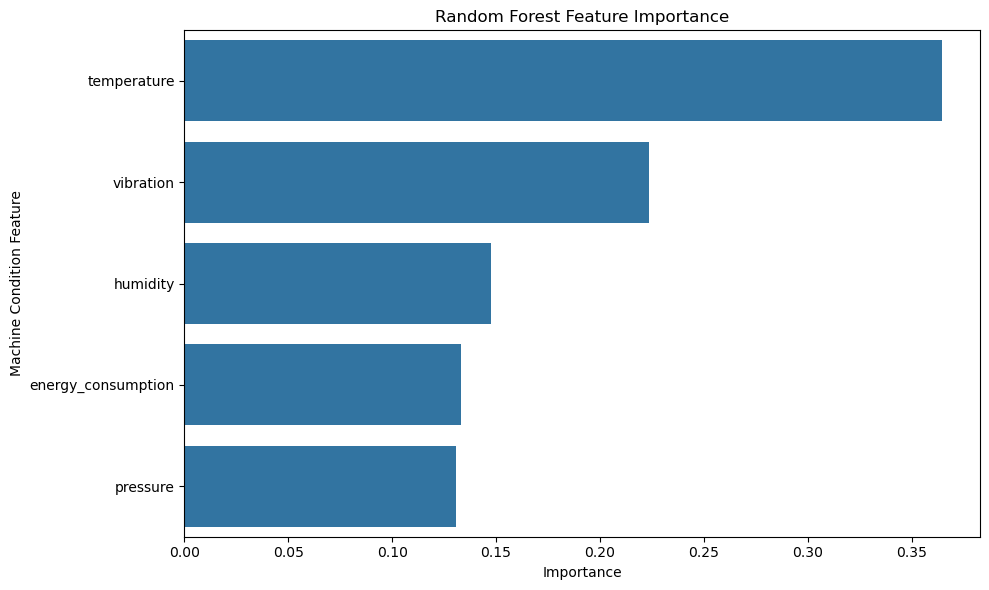

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Machine Condition Feature")
plt.tight_layout()
plt.show()

## 4.4 Maintenance Risk Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for
predictive maintenance.

Because failing to identify a machine that genuinely requires maintenance can
lead to unexpected downtime, the decision threshold is evaluated to determine
whether recall can be improved while maintaining an acceptable level of
precision.

The threshold will be selected based on the business objective rather than
accuracy alone.

In [47]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_probabilities
)

threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_results["f1"] = (
    2
    * threshold_results["precision"]
    * threshold_results["recall"]
    / (
        threshold_results["precision"]
        + threshold_results["recall"]
    )
)

threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
83,0.840,1.000,0.449,0.620
82,0.655,0.999,0.449,0.619
81,0.485,0.999,0.449,0.619
84,0.900,1.000,0.449,0.619
80,0.450,0.998,0.449,0.619
79,0.445,0.998,0.449,0.619
85,0.945,1.000,0.448,0.619
78,0.430,0.997,0.449,0.619
86,0.955,1.000,0.448,0.619
77,0.420,0.996,0.449,0.619


In [48]:
recall_target = 0.70

eligible_thresholds = threshold_results[
    threshold_results["recall"] >= recall_target
].copy()

eligible_thresholds.sort_values(
    "precision",
    ascending=False
).head(10)

,threshold,precision,recall,f1
21,0.115,0.263,0.720,0.386
20,0.110,0.254,0.746,0.379
19,0.105,0.245,0.763,0.371
18,0.100,0.238,0.787,0.365
17,0.095,0.231,0.809,0.360
16,0.090,0.226,0.832,0.355
15,0.085,0.221,0.855,0.351
14,0.080,0.216,0.878,0.347
13,0.075,0.212,0.898,0.343
12,0.070,0.209,0.919,0.340


In [49]:
recall_target = 0.70

eligible_thresholds = threshold_results[
    threshold_results["recall"] >= recall_target
].copy()

eligible_thresholds.sort_values(
    "precision",
    ascending=False
).head(10)

,threshold,precision,recall,f1
21,0.115,0.263,0.720,0.386
20,0.110,0.254,0.746,0.379
19,0.105,0.245,0.763,0.371
18,0.100,0.238,0.787,0.365
17,0.095,0.231,0.809,0.360
16,0.090,0.226,0.832,0.355
15,0.085,0.221,0.855,0.351
14,0.080,0.216,0.878,0.347
13,0.075,0.212,0.898,0.343
12,0.070,0.209,0.919,0.340


In [50]:
best_threshold_row = (
    eligible_thresholds
    .sort_values("precision", ascending=False)
    .iloc[0]
)

best_threshold = best_threshold_row["threshold"]

print("Selected threshold:", round(best_threshold, 4))
print("Precision:", round(best_threshold_row["precision"], 4))
print("Recall:", round(best_threshold_row["recall"], 4))
print("F1:", round(best_threshold_row["f1"], 4))

Selected threshold: 0.115
Precision: 0.2633
Recall: 0.72
F1: 0.3856


In [51]:
rf_optimized_predictions = (
    rf_probabilities >= best_threshold
).astype(int)

optimized_accuracy = accuracy_score(
    y_test,
    rf_optimized_predictions
)

optimized_precision = precision_score(
    y_test,
    rf_optimized_predictions,
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    rf_optimized_predictions,
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    rf_optimized_predictions,
    zero_division=0
)

print("Optimized Random Forest")
print("-" * 40)
print(f"Threshold: {best_threshold:.4f}")
print(f"Accuracy:  {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall:    {optimized_recall:.4f}")
print(f"F1 Score:  {optimized_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

Optimized Random Forest
----------------------------------------
Threshold: 0.1150
Accuracy:  0.5481
Precision: 0.2633
Recall:    0.7200
F1 Score:  0.3856
ROC-AUC:   0.7235


## 4.5 Final Predictive Maintenance Model Comparison

The baseline Logistic Regression, default Random Forest, and threshold-
optimized Random Forest are compared.

The final model will be selected using both statistical performance and the
business objective of detecting machines that genuinely require maintenance.

In [52]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        optimized_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        optimized_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        optimized_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        optimized_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc,
        rf_auc
    ]
})

final_model_comparison.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.635,0.297,0.625,0.403,0.693
1,Random Forest,0.891,0.999,0.449,0.620,0.724
2,Optimized Random Forest,0.548,0.263,0.720,0.386,0.724


# 5. Industrial Energy Analysis

The industrial energy dataset provides machine-level information about energy
consumption, production output, machine utilization, electrical conditions,
operating mode, and energy recommendations.

This component investigates how energy consumption relates to production and
machine operating conditions.

The objective is to identify inefficient operating patterns and develop
practical recommendations for reducing energy consumption while maintaining
productive output.

In [53]:
energy_df.head()

,timestamp,machine_id,operation_id,energy_kWh,voltage_V,current_A,power_factor,reactive_power_kVAR,frequency_Hz,machine_utilization_%,production_output_units,operator_count,material_usage_kg,ambient_temp_C,humidity_%,shift_type,production_mode,forecast_energy_kWh,energy_state,allocation_recommendation
0,2025-07-01 00:00:00,MCH_1,OP_05,9.750,395.410,24.660,0.974,3.420,50.040,60.950,119,4,57.530,22.140,50.930,Night,Idle,11.180,Normal,Maintain
1,2025-07-01 00:05:00,MCH_1,OP_01,10.640,400.630,26.550,0.859,2.780,49.910,66.770,88,3,57.320,28.020,61.630,Night,Setup,11.250,High,Reduce Load
2,2025-07-01 00:10:00,MCH_1,OP_08,10.920,395.180,27.640,0.898,3.340,50.040,60.860,84,2,45.520,29.380,59.820,Day,Setup,10.690,High,Reduce Load
3,2025-07-01 00:15:00,MCH_1,OP_05,10.870,405.200,26.830,0.935,3.900,49.910,69.510,96,3,58.550,24.300,46.940,Night,Idle,12.940,High,Reduce Load
4,2025-07-01 00:20:00,MCH_1,OP_05,10.070,400.870,25.130,0.966,4.340,49.900,82.900,104,3,42.410,25.490,56.390,Day,Production,9.690,High,Reduce Load


In [54]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  1200 non-null   datetime64[ns]
 1   machine_id                 1200 non-null   object        
 2   operation_id               1200 non-null   object        
 3   energy_kWh                 1200 non-null   float64       
 4   voltage_V                  1200 non-null   float64       
 5   current_A                  1200 non-null   float64       
 6   power_factor               1200 non-null   float64       
 7   reactive_power_kVAR        1200 non-null   float64       
 8   frequency_Hz               1200 non-null   float64       
 9   machine_utilization_%      1200 non-null   float64       
 10  production_output_units    1200 non-null   int64         
 11  operator_count             1200 non-null   int64         
 12  materi

In [55]:
energy_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,1200,NaN,NaN,NaN,2025-07-01 09:57:30.000000256,2025-07-01 00:00:00,2025-07-01 04:58:45,2025-07-01 09:57:30,2025-07-01 14:56:15,2025-07-01 19:55:00,NaN
machine_id,1200,5,MCH_1,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operation_id,1200,10,OP_03,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy_kWh,1200.000,NaN,NaN,NaN,11.846,6.480,9.670,11.535,13.562,19.790,2.818
voltage_V,1200.000,NaN,NaN,NaN,400.168,379.670,397.027,400.150,403.473,414.650,4.884
current_A,1200.000,NaN,NaN,NaN,29.604,16.040,24.148,28.875,34.050,50.300,7.039
power_factor,1200.000,NaN,NaN,NaN,0.914,0.850,0.882,0.914,0.947,0.980,0.038
reactive_power_kVAR,1200.000,NaN,NaN,NaN,3.516,2.000,2.770,3.515,4.272,5.000,0.863
frequency_Hz,1200.000,NaN,NaN,NaN,49.991,49.660,49.920,49.990,50.060,50.380,0.102
machine_utilization_%,1200.000,NaN,NaN,NaN,78.374,60.010,69.418,78.875,87.165,95.000,10.260


## 5.1 Energy Dataset Quality Assessment

The energy dataset is checked for missing values, duplicate observations,
unique machines, operating modes, and production conditions before analysis.

In [56]:
print("Missing values:")
display(energy_df.isnull().sum())

print("\nDuplicate rows:")
print(energy_df.duplicated().sum())

print("\nNumber of machines:")
print(energy_df["machine_id"].nunique())

print("\nMachines:")
print(energy_df["machine_id"].unique())

Missing values:


timestamp                    0
machine_id                   0
operation_id                 0
energy_kWh                   0
voltage_V                    0
current_A                    0
power_factor                 0
reactive_power_kVAR          0
frequency_Hz                 0
machine_utilization_%        0
production_output_units      0
operator_count               0
material_usage_kg            0
ambient_temp_C               0
humidity_%                   0
shift_type                   0
production_mode              0
forecast_energy_kWh          0
energy_state                 0
allocation_recommendation    0
dtype: int64


Duplicate rows:
0

Number of machines:
5

Machines:
['MCH_1' 'MCH_2' 'MCH_3' 'MCH_4' 'MCH_5']


In [57]:
print("Missing values:")
display(energy_df.isnull().sum())

print("\nDuplicate rows:")
print(energy_df.duplicated().sum())

print("\nNumber of machines:")
print(energy_df["machine_id"].nunique())

print("\nMachines:")
print(energy_df["machine_id"].unique())

Missing values:


timestamp                    0
machine_id                   0
operation_id                 0
energy_kWh                   0
voltage_V                    0
current_A                    0
power_factor                 0
reactive_power_kVAR          0
frequency_Hz                 0
machine_utilization_%        0
production_output_units      0
operator_count               0
material_usage_kg            0
ambient_temp_C               0
humidity_%                   0
shift_type                   0
production_mode              0
forecast_energy_kWh          0
energy_state                 0
allocation_recommendation    0
dtype: int64


Duplicate rows:
0

Number of machines:
5

Machines:
['MCH_1' 'MCH_2' 'MCH_3' 'MCH_4' 'MCH_5']


In [58]:
categorical_energy = energy_df.select_dtypes(
    include="object"
).columns

for column in categorical_energy:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(energy_df[column].value_counts())


machine_id
machine_id
MCH_1    240
MCH_2    240
MCH_3    240
MCH_4    240
MCH_5    240
Name: count, dtype: int64

operation_id
operation_id
OP_03    139
OP_01    129
OP_04    127
OP_02    127
OP_07    122
OP_10    121
OP_05    112
OP_09    111
OP_08    107
OP_06    105
Name: count, dtype: int64

shift_type
shift_type
Night    621
Day      579
Name: count, dtype: int64

production_mode
production_mode
Production     308
Idle           304
Maintenance    299
Setup          289
Name: count, dtype: int64

energy_state
energy_state
High      854
Normal    346
Name: count, dtype: int64

allocation_recommendation
allocation_recommendation
Reduce Load    854
Maintain       346
Name: count, dtype: int64


## Business Question 6

### Which machines consume the most energy?

Identifying high-energy-consuming machines allows management to focus
efficiency interventions on the areas with the greatest potential impact.

Average energy consumption is compared across machines.

In [59]:
machine_energy = (
    energy_df
    .groupby("machine_id")["energy_kWh"]
    .agg(
        average_energy="mean",
        total_energy="sum",
        maximum_energy="max"
    )
    .sort_values(
        "total_energy",
        ascending=False
    )
)

machine_energy

,average_energy,total_energy,maximum_energy
machine_id,,,
MCH_2,14.808,3553.830,19.790
MCH_4,13.846,3323.000,18.020
MCH_5,11.205,2689.230,14.800
MCH_1,10.376,2490.240,14.270
MCH_3,8.996,2159.020,11.700


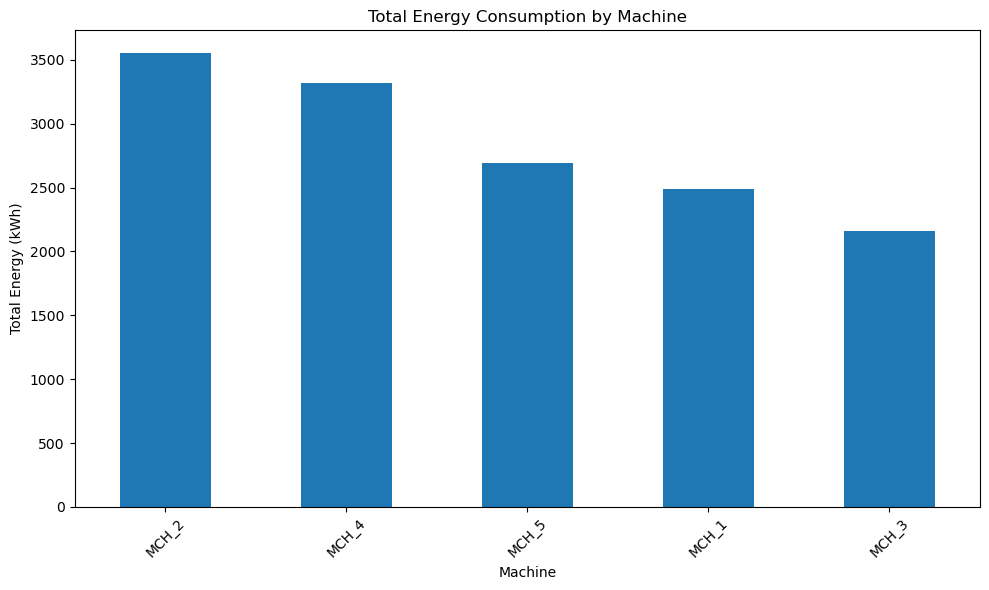

In [60]:
plt.figure(figsize=(10, 6))

machine_energy["total_energy"].plot(
    kind="bar"
)

plt.title("Total Energy Consumption by Machine")
plt.xlabel("Machine")
plt.ylabel("Total Energy (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Question 7

### How efficiently is energy being converted into production output?

Energy consumption alone does not tell us whether a machine is inefficient.

A machine may consume more energy because it produces substantially more output.

Therefore, an energy-efficiency indicator is calculated as production output
per unit of energy consumed.

Higher values indicate that more production output is obtained from each unit
of energy.

In [61]:
energy_df["energy_efficiency"] = (
    energy_df["production_output_units"]
    / energy_df["energy_kWh"].replace(0, np.nan)
)

energy_df[
    [
        "machine_id",
        "energy_kWh",
        "production_output_units",
        "energy_efficiency"
    ]
].head()

,machine_id,energy_kWh,production_output_units,energy_efficiency
0,MCH_1,9.750,119,12.205
1,MCH_1,10.640,88,8.271
2,MCH_1,10.920,84,7.692
3,MCH_1,10.870,96,8.832
4,MCH_1,10.070,104,10.328


In [62]:
machine_efficiency = (
    energy_df
    .groupby("machine_id")["energy_efficiency"]
    .agg(
        average_efficiency="mean",
        median_efficiency="median"
    )
    .sort_values(
        "average_efficiency",
        ascending=False
    )
)

machine_efficiency

,average_efficiency,median_efficiency
machine_id,,
MCH_3,11.388,11.134
MCH_1,9.909,9.771
MCH_5,9.222,9.058
MCH_4,7.347,7.156
MCH_2,6.887,6.701


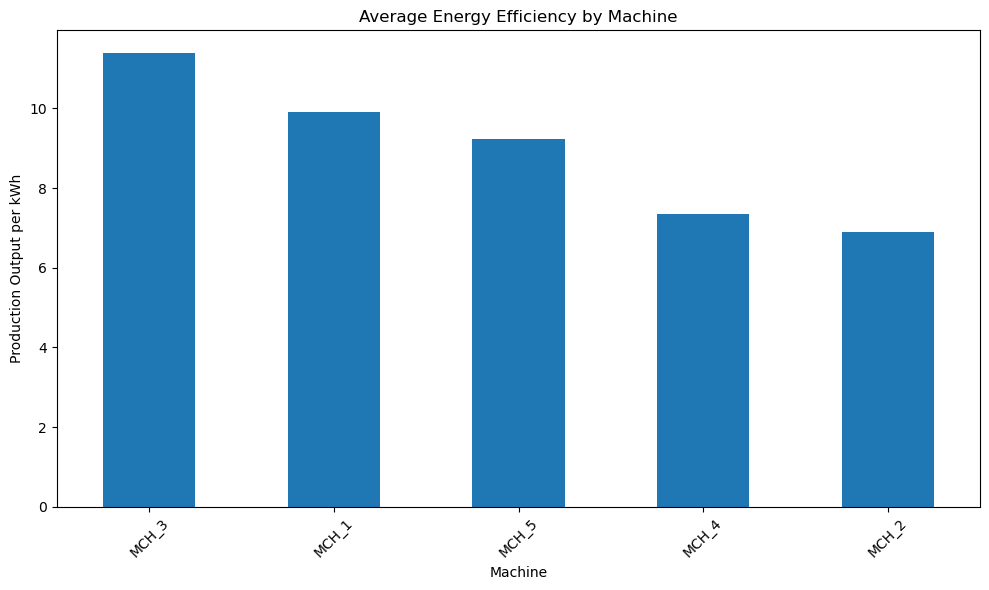

In [63]:
plt.figure(figsize=(10, 6))

machine_efficiency["average_efficiency"].plot(
    kind="bar"
)

plt.title("Average Energy Efficiency by Machine")
plt.xlabel("Machine")
plt.ylabel("Production Output per kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Question 8

### Where is actual energy consumption exceeding the forecast?

Comparing actual energy consumption with forecast consumption can identify
periods where machines consume more energy than expected.

Persistent positive deviations may indicate inefficient operation or unusual
machine behavior.

In [64]:
energy_df["energy_variance"] = (
    energy_df["energy_kWh"]
    - energy_df["forecast_energy_kWh"]
)

energy_df[
    [
        "machine_id",
        "energy_kWh",
        "forecast_energy_kWh",
        "energy_variance"
    ]
].head()

,machine_id,energy_kWh,forecast_energy_kWh,energy_variance
0,MCH_1,9.750,11.180,-1.430
1,MCH_1,10.640,11.250,-0.610
2,MCH_1,10.920,10.690,0.230
3,MCH_1,10.870,12.940,-2.070
4,MCH_1,10.070,9.690,0.380


In [65]:
energy_variance_by_machine = (
    energy_df
    .groupby("machine_id")["energy_variance"]
    .agg(
        average_variance="mean",
        total_variance="sum"
    )
    .sort_values(
        "average_variance",
        ascending=False
    )
)

energy_variance_by_machine

,average_variance,total_variance
machine_id,,
MCH_5,0.125,29.970
MCH_4,0.053,12.810
MCH_2,0.037,8.980
MCH_3,-0.024,-5.750
MCH_1,-0.041,-9.880


## 5.2 Machine Energy Performance Profile

Energy efficiency and energy variance provide complementary measures of machine
performance.

### Energy Efficiency

Energy efficiency measures production output generated per unit of energy
consumed.

Higher values indicate better energy productivity.

### Energy Variance

Energy variance measures the difference between actual and forecast energy
consumption.

Positive values indicate that actual energy consumption exceeded the expected
level, while negative values indicate consumption below the forecast.

Both indicators are used to identify machines that may require energy-efficiency
interventions.

In [66]:
energy_profile = (
    energy_df
    .groupby("machine_id")
    .agg(
        avg_energy_kWh=("energy_kWh", "mean"),
        total_energy_kWh=("energy_kWh", "sum"),
        avg_production=("production_output_units", "mean"),
        total_production=("production_output_units", "sum"),
        avg_efficiency=("energy_efficiency", "mean"),
        avg_energy_variance=("energy_variance", "mean"),
        total_energy_variance=("energy_variance", "sum"),
        avg_utilization=("machine_utilization_%", "mean")
    )
    .reset_index()
)

energy_profile

,machine_id,avg_energy_kWh,total_energy_kWh,avg_production,total_production,avg_efficiency,avg_energy_variance,total_energy_variance,avg_utilization
0,MCH_1,10.376,2490.240,100.521,24125,9.909,-0.041,-9.880,77.581
1,MCH_2,14.808,3553.830,99.592,23902,6.887,0.037,8.980,78.886
2,MCH_3,8.996,2159.020,100.142,24034,11.388,-0.024,-5.750,78.369
3,MCH_4,13.846,3323.000,99.492,23878,7.347,0.053,12.810,78.741
4,MCH_5,11.205,2689.230,100.921,24221,9.222,0.125,29.970,78.291


## 5.3 Energy Performance Classification

Machines are classified using two indicators:

1. Energy efficiency
2. Actual energy consumption relative to forecast

A machine with high efficiency and consumption below forecast represents a
strong energy-performance profile.

A machine with low efficiency and consumption above forecast represents a
higher-priority optimization opportunity.

This classification is used as a decision-support mechanism rather than as a
formal machine-learning target.

In [67]:
efficiency_median = energy_profile["avg_efficiency"].median()
variance_median = energy_profile["avg_energy_variance"].median()

def classify_energy_performance(row):
    high_efficiency = row["avg_efficiency"] >= efficiency_median
    below_forecast = row["avg_energy_variance"] <= variance_median

    if high_efficiency and below_forecast:
        return "Efficient"

    if high_efficiency and not below_forecast:
        return "Efficient but Above Forecast"

    if not high_efficiency and below_forecast:
        return "Less Efficient but Below Forecast"

    return "Optimization Priority"


energy_profile["energy_performance"] = (
    energy_profile.apply(
        classify_energy_performance,
        axis=1
    )
)

energy_profile

,machine_id,avg_energy_kWh,total_energy_kWh,avg_production,total_production,avg_efficiency,avg_energy_variance,total_energy_variance,avg_utilization,energy_performance
0,MCH_1,10.376,2490.240,100.521,24125,9.909,-0.041,-9.880,77.581,Efficient
1,MCH_2,14.808,3553.830,99.592,23902,6.887,0.037,8.980,78.886,Less Efficient but Below Forecast
2,MCH_3,8.996,2159.020,100.142,24034,11.388,-0.024,-5.750,78.369,Efficient
3,MCH_4,13.846,3323.000,99.492,23878,7.347,0.053,12.810,78.741,Optimization Priority
4,MCH_5,11.205,2689.230,100.921,24221,9.222,0.125,29.970,78.291,Efficient but Above Forecast


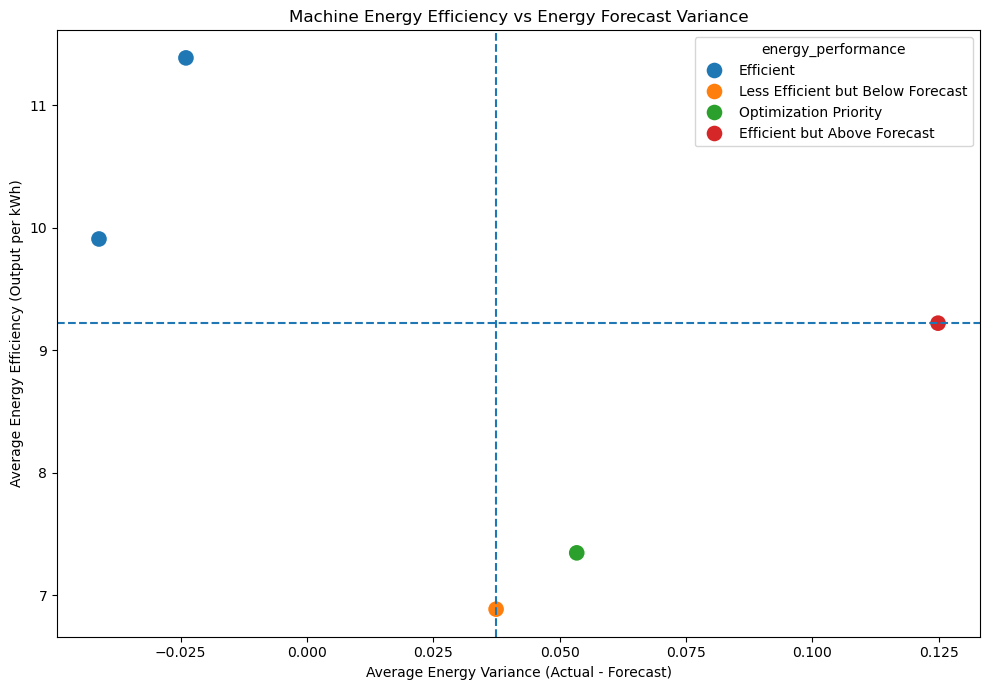

In [68]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=energy_profile,
    x="avg_energy_variance",
    y="avg_efficiency",
    hue="energy_performance",
    s=150
)

plt.axvline(
    variance_median,
    linestyle="--"
)

plt.axhline(
    efficiency_median,
    linestyle="--"
)

plt.title(
    "Machine Energy Efficiency vs Energy Forecast Variance"
)

plt.xlabel(
    "Average Energy Variance (Actual - Forecast)"
)

plt.ylabel(
    "Average Energy Efficiency (Output per kWh)"
)

plt.tight_layout()
plt.show()

## Business Question 9

### Does production mode affect energy efficiency?

Manufacturing equipment may operate under different production modes that
require different energy levels.

Comparing energy consumption and efficiency across production modes can reveal
operating conditions where energy use can potentially be reduced without
unnecessarily reducing production output.

In [69]:
mode_analysis = (
    energy_df
    .groupby("production_mode")
    .agg(
        avg_energy=("energy_kWh", "mean"),
        avg_production=("production_output_units", "mean"),
        avg_efficiency=("energy_efficiency", "mean"),
        avg_variance=("energy_variance", "mean"),
        observations=("production_mode", "size")
    )
    .sort_values(
        "avg_efficiency",
        ascending=False
    )
)

mode_analysis

,avg_energy,avg_production,avg_efficiency,avg_variance,observations
production_mode,,,,,
Setup,11.672,100.370,9.132,-0.012,289
Maintenance,11.805,101.130,9.030,0.087,299
Idle,11.904,99.276,8.860,-0.083,304
Production,11.992,99.789,8.794,0.126,308


In [70]:
utilization_analysis = (
    energy_df
    .groupby("machine_id")
    .agg(
        avg_utilization=("machine_utilization_%", "mean"),
        avg_energy=("energy_kWh", "mean"),
        avg_efficiency=("energy_efficiency", "mean")
    )
    .sort_values(
        "avg_efficiency",
        ascending=False
    )
)

utilization_analysis

,avg_utilization,avg_energy,avg_efficiency
machine_id,,,
MCH_3,78.369,8.996,11.388
MCH_1,77.581,10.376,9.909
MCH_5,78.291,11.205,9.222
MCH_4,78.741,13.846,7.347
MCH_2,78.886,14.808,6.887


In [72]:
utilization_energy_corr = energy_df[
    [
        "machine_utilization_%",
        "energy_kWh",
        "production_output_units",
        "energy_efficiency"
    ]
].corr()

utilization_energy_corr

,machine_utilization_%,energy_kWh,production_output_units,energy_efficiency
machine_utilization_%,1.000,0.030,0.002,-0.020
energy_kWh,0.030,1.000,-0.032,-0.888
production_output_units,0.002,-0.032,1.000,0.407
energy_efficiency,-0.020,-0.888,0.407,1.000


## Business Question 10

### Which operational and electrical variables are associated with energy
consumption?

Energy consumption can be influenced by electrical characteristics and
operating conditions.

The relationships between energy consumption and variables such as voltage,
current, power factor, machine utilization, production output, and operating
mode are examined to identify potential energy-efficiency drivers.

Correlation analysis is treated as exploratory evidence and is not interpreted
as proof of causation.

In [73]:
energy_numeric = energy_df.select_dtypes(
    include=np.number
)

energy_consumption_corr = (
    energy_numeric.corr()["energy_kWh"]
    .sort_values(ascending=False)
)

energy_consumption_corr

energy_kWh                 1.000
current_A                  0.999
forecast_energy_kWh        0.944
energy_variance            0.045
voltage_V                  0.034
machine_utilization_%      0.030
power_factor               0.017
frequency_Hz               0.010
operator_count            -0.015
humidity_%                -0.018
ambient_temp_C            -0.028
production_output_units   -0.032
reactive_power_kVAR       -0.040
material_usage_kg         -0.071
energy_efficiency         -0.888
Name: energy_kWh, dtype: float64

In [74]:
energy_df.columns.tolist()

['timestamp',
 'machine_id',
 'operation_id',
 'energy_kWh',
 'voltage_V',
 'current_A',
 'power_factor',
 'reactive_power_kVAR',
 'frequency_Hz',
 'machine_utilization_%',
 'production_output_units',
 'operator_count',
 'material_usage_kg',
 'ambient_temp_C',
 'humidity_%',
 'shift_type',
 'production_mode',
 'forecast_energy_kWh',
 'energy_state',
 'allocation_recommendation',
 'energy_efficiency',
 'energy_variance']

In [75]:
electrical_columns = [
    column
    for column in energy_df.columns
    if any(
        term in column.lower()
        for term in [
            "voltage",
            "current",
            "power",
            "factor"
        ]
    )
]

electrical_columns

['voltage_V', 'current_A', 'power_factor', 'reactive_power_kVAR']

In [76]:
electrical_columns = [
    column
    for column in energy_df.columns
    if any(
        term in column.lower()
        for term in [
            "voltage",
            "current",
            "power",
            "factor"
        ]
    )
]

electrical_columns

['voltage_V', 'current_A', 'power_factor', 'reactive_power_kVAR']

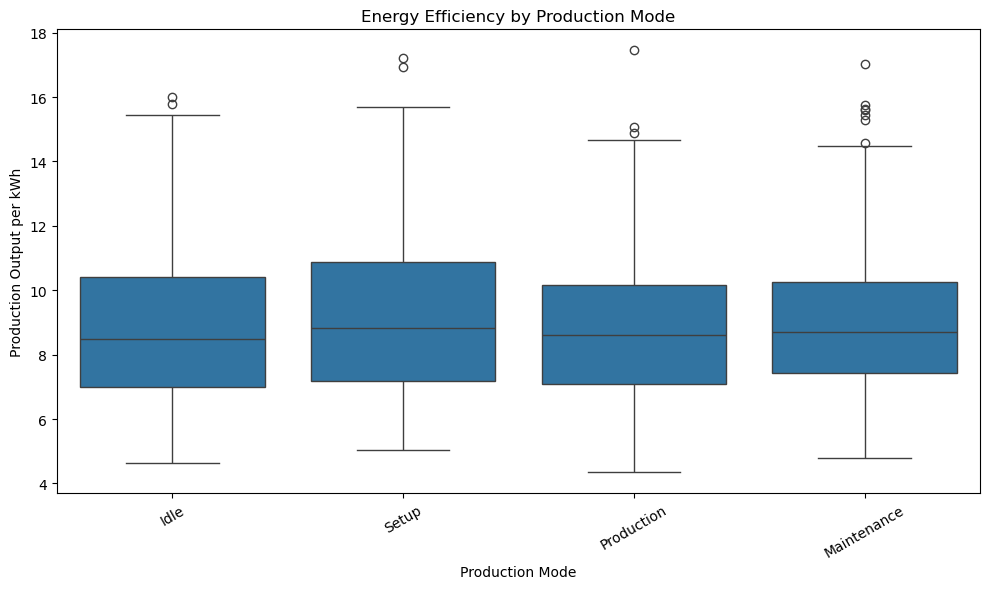

In [77]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=energy_df,
    x="production_mode",
    y="energy_efficiency"
)

plt.title("Energy Efficiency by Production Mode")
plt.xlabel("Production Mode")
plt.ylabel("Production Output per kWh")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

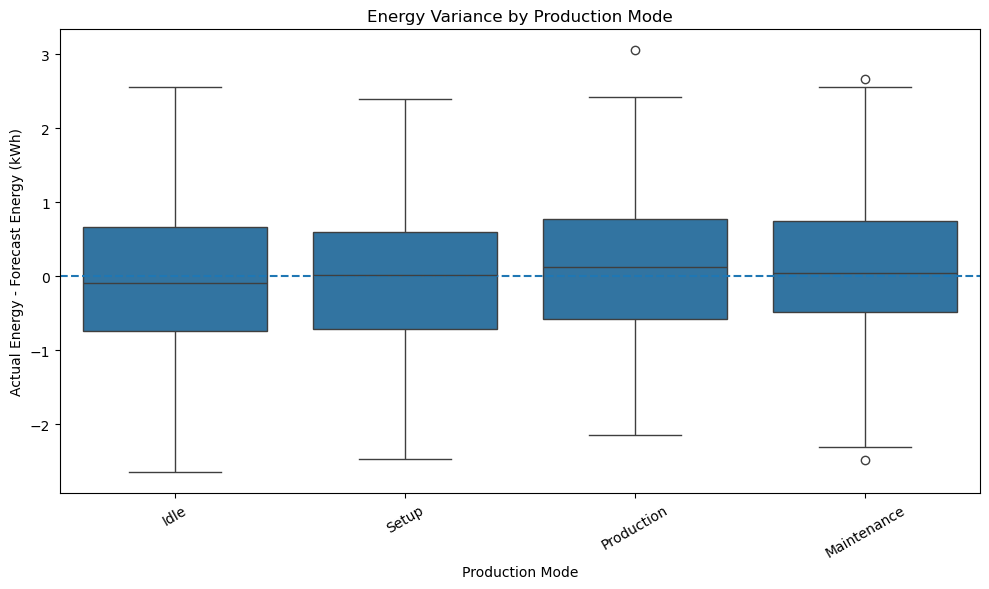

In [78]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=energy_df,
    x="production_mode",
    y="energy_variance"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Energy Variance by Production Mode")
plt.xlabel("Production Mode")
plt.ylabel("Actual Energy - Forecast Energy (kWh)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5.4 Energy Optimization Priority Score

A practical optimization priority score is developed to rank machines for
energy-efficiency intervention.

The score considers two dimensions:

1. Energy efficiency
2. Energy consumption relative to forecast

Machines with lower efficiency and higher positive energy variance receive
higher optimization priority.

The score is intended as a decision-support indicator rather than a causal
measure of energy waste.

In [79]:
# Normalize the two optimization indicators

energy_profile["efficiency_score"] = (
    1
    - (
        energy_profile["avg_efficiency"]
        - energy_profile["avg_efficiency"].min()
    )
    / (
        energy_profile["avg_efficiency"].max()
        - energy_profile["avg_efficiency"].min()
    )
)

energy_profile["variance_score"] = (
    (
        energy_profile["avg_energy_variance"]
        - energy_profile["avg_energy_variance"].min()
    )
    / (
        energy_profile["avg_energy_variance"].max()
        - energy_profile["avg_energy_variance"].min()
    )
)

# Combined optimization priority
energy_profile["optimization_score"] = (
    0.6 * energy_profile["efficiency_score"]
    + 0.4 * energy_profile["variance_score"]
)

energy_profile[
    [
        "machine_id",
        "avg_efficiency",
        "avg_energy_variance",
        "optimization_score"
    ]
].sort_values(
    "optimization_score",
    ascending=False
)

,machine_id,avg_efficiency,avg_energy_variance,optimization_score
1,MCH_2,6.887,0.037,0.789
3,MCH_4,7.347,0.053,0.766
4,MCH_5,9.222,0.125,0.689
0,MCH_1,9.909,-0.041,0.197
2,MCH_3,11.388,-0.024,0.041


In [80]:
def optimization_recommendation(row):
    score = row["optimization_score"]

    if score >= 0.70:
        return "High Priority: Investigate energy efficiency and operating conditions"

    elif score >= 0.40:
        return "Medium Priority: Monitor energy performance and review operating mode"

    return "Low Priority: Maintain current energy-performance practices"


energy_profile["optimization_recommendation"] = (
    energy_profile.apply(
        optimization_recommendation,
        axis=1
    )
)

energy_profile[
    [
        "machine_id",
        "avg_efficiency",
        "avg_energy_variance",
        "optimization_score",
        "energy_performance",
        "optimization_recommendation"
    ]
].sort_values(
    "optimization_score",
    ascending=False
)

,machine_id,avg_efficiency,avg_energy_variance,optimization_score,energy_performance,optimization_recommendation
1,MCH_2,6.887,0.037,0.789,Less Efficient but Below Forecast,High Priority: Investigate energy efficiency a...
3,MCH_4,7.347,0.053,0.766,Optimization Priority,High Priority: Investigate energy efficiency a...
4,MCH_5,9.222,0.125,0.689,Efficient but Above Forecast,Medium Priority: Monitor energy performance an...
0,MCH_1,9.909,-0.041,0.197,Efficient,Low Priority: Maintain current energy-performa...
2,MCH_3,11.388,-0.024,0.041,Efficient,Low Priority: Maintain current energy-performa...


# 6. Integrated Smart Manufacturing Decision Framework

The predictive-maintenance model and energy-optimization framework are combined
to create an integrated decision-support system.

The framework considers two dimensions:

1. Machine maintenance risk
2. Energy optimization priority

This allows machines to be evaluated from both a reliability and energy-
efficiency perspective.

The objective is not to automatically make maintenance decisions, but to
provide actionable information that can support manufacturing management.

In [81]:
# Predict maintenance probability for all manufacturing observations

manufacturing_model_data = manufacturing_df.copy()

manufacturing_model_data["maintenance_probability"] = (
    random_forest_model.predict_proba(
        manufacturing_model_data[features]
    )[:, 1]
)

manufacturing_model_data["predicted_maintenance"] = (
    manufacturing_model_data["maintenance_probability"] >= 0.50
).astype(int)

manufacturing_model_data[
    [
        "machine_id",
        "timestamp",
        "maintenance_probability",
        "predicted_maintenance"
    ]
].head()

,machine_id,timestamp,maintenance_probability,predicted_maintenance
0,39,2025-01-01 00:00:00,0.035,0
1,29,2025-01-01 00:01:00,0.080,0
2,15,2025-01-01 00:02:00,0.995,1
3,43,2025-01-01 00:03:00,0.995,1
4,8,2025-01-01 00:04:00,0.165,0


In [82]:
maintenance_profile = (
    manufacturing_model_data
    .groupby("machine_id")
    .agg(
        avg_temperature=("temperature", "mean"),
        avg_vibration=("vibration", "mean"),
        avg_energy_consumption=("energy_consumption", "mean"),
        actual_maintenance_rate=("maintenance_required", "mean"),
        predicted_maintenance_rate=("predicted_maintenance", "mean"),
        avg_maintenance_probability=(
            "maintenance_probability",
            "mean"
        )
    )
    .reset_index()
)

maintenance_profile["actual_maintenance_rate"] *= 100
maintenance_profile["predicted_maintenance_rate"] *= 100

maintenance_profile.head()

,machine_id,avg_temperature,avg_vibration,avg_energy_consumption,actual_maintenance_rate,predicted_maintenance_rate,avg_maintenance_probability
0,1,74.863,50.344,2.730,20.355,18.319,0.206
1,2,74.969,49.958,2.683,20.186,17.687,0.195
2,3,74.796,50.566,2.801,19.040,16.892,0.190
3,4,74.935,49.790,2.788,20.609,18.663,0.209
4,5,74.970,49.225,2.746,20.950,18.453,0.201


## 6.1 Machine Maintenance Risk Classification

Average predicted maintenance probability is converted into practical risk
categories.

The categories are intended for decision support and should not be interpreted
as guaranteed machine-failure probabilities.

In [83]:
def maintenance_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    return "Low Risk"


maintenance_profile["maintenance_risk"] = (
    maintenance_profile["avg_maintenance_probability"]
    .apply(maintenance_risk)
)

maintenance_profile[
    [
        "machine_id",
        "avg_maintenance_probability",
        "maintenance_risk"
    ]
].sort_values(
    "avg_maintenance_probability",
    ascending=False
)

,machine_id,avg_maintenance_probability,maintenance_risk
42,43,0.215,Low Risk
49,50,0.210,Low Risk
3,4,0.209,Low Risk
5,6,0.209,Low Risk
28,29,0.209,Low Risk
27,28,0.207,Low Risk
0,1,0.206,Low Risk
31,32,0.206,Low Risk
29,30,0.205,Low Risk
23,24,0.205,Low Risk


# 7. Executive KPI Framework

The final application will communicate the most important project indicators
through a set of executive-level KPIs.

The KPIs provide a high-level view of:

- Machine maintenance risk
- Manufacturing anomaly rate
- Energy consumption
- Energy efficiency
- Energy deviation from forecast
- Machines requiring optimization attention

In [84]:
# Manufacturing KPIs

total_manufacturing_records = len(manufacturing_df)

maintenance_rate = (
    manufacturing_df["maintenance_required"].mean() * 100
)

anomaly_rate = (
    manufacturing_df["anomaly_flag"].mean() * 100
)

high_risk_machine_count = (
    maintenance_profile["maintenance_risk"]
    .eq("High Risk")
    .sum()
)

# Energy KPIs

total_energy_consumption = energy_df["energy_kWh"].sum()

average_energy_efficiency = (
    energy_df["energy_efficiency"].mean()
)

above_forecast_records = (
    energy_df["energy_variance"] > 0
).sum()

optimization_priority_count = (
    energy_profile["energy_performance"]
    .eq("Optimization Priority")
    .sum()
)

print("Manufacturing records:", total_manufacturing_records)
print("Maintenance rate:", round(maintenance_rate, 2), "%")
print("Anomaly rate:", round(anomaly_rate, 2), "%")
print("High-risk machines:", high_risk_machine_count)

print("\nTotal energy consumption:", round(
    total_energy_consumption, 2
), "kWh")

print("Average energy efficiency:", round(
    average_energy_efficiency, 2
))

print("Records above forecast:", above_forecast_records)
print("Optimization-priority machines:", optimization_priority_count)

Manufacturing records: 100000
Maintenance rate: 19.7 %
Anomaly rate: 8.92 %
High-risk machines: 0

Total energy consumption: 14215.32 kWh
Average energy efficiency: 8.95
Records above forecast: 612
Optimization-priority machines: 1


In [85]:
import os

os.makedirs("project_outputs", exist_ok=True)

maintenance_profile.to_csv(
    "project_outputs/maintenance_profile.csv",
    index=False
)

energy_profile.to_csv(
    "project_outputs/energy_profile.csv",
    index=False
)

model_comparison.to_csv(
    "project_outputs/model_comparison.csv",
    index=False
)

print("Project outputs saved successfully.")

Project outputs saved successfully.


In [86]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "models/predictive_maintenance_model.pkl"
)

print("Predictive maintenance model saved.")

Predictive maintenance model saved.


In [87]:
joblib.dump(
    features,
    "models/model_features.pkl"
)

print("Model feature list saved.")

Model feature list saved.
